# Forecasting of El Niño
___

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from preprocess import preprocess

In [2]:
data, _, __ = preprocess()

### Creating supervised datasets

In [3]:
def create_supervised_dataset(df, target_col, lead_time=1, n_lags=6, include_month=False):
    X = pd.DataFrame(index=df.index)

    # lags for the chosen target
    for lag in range(n_lags + 1):
        X[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    if include_month:
        months = df.index.month
        X["sin_month"] = np.sin(2*np.pi*months/12)
        X["cos_month"] = np.cos(2*np.pi*months/12)

    y = df[target_col].shift(-lead_time)  # absolute target
    
    enso_test = data['EN_34'].shift(-lead_time).dropna()
    combined = pd.concat([X, y.rename("target"), enso_test.rename("test")], axis=1).dropna()
    
    return combined.drop(columns=["target", "test"]), combined["target"], combined["test"]

### Preparing the ML Framework

In [4]:
def plot_test(model, data, leads_to_plot, n_lags=12, split=0.8, regressor_kwargs=None, model_name=None):

    if regressor_kwargs is None:
        regressor_kwargs = {}
    if model_name is None:
        model_name = model.__name__

    fig, axes = plt.subplots(
        nrows=len(leads_to_plot),
        ncols=3,
        figsize=(20, 3 * len(leads_to_plot)),
        sharex=True,
        constrained_layout=True)
    if len(leads_to_plot) == 1:
        axes = np.expand_dims(axes, axis=0)

    lr = LinearRegression().fit(data[["PC1", "PC2"]][int(len(data) * split):].values, data["EN_34"][int(len(data) * split):].values)

    for row_idx, lead in enumerate(leads_to_plot):
        ax_pc1, ax_pc2, ax_en34 = axes[row_idx, 0], axes[row_idx, 1], axes[row_idx, 2]

        preds_abs = {}
        true_abs  = {}

        # PC1 and PC2 forecasts
        for target, ax in [("PC1", ax_pc1), ("PC2", ax_pc2)]:
            X, y, true_enso_test = create_supervised_dataset(data, target, lead_time=lead, n_lags=n_lags)

            split_point = int(len(X) * split)
            X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
            y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

            reg = model(**regressor_kwargs)
            reg.fit(X_train, y_train)

            pred_diff = reg.predict(X_test)

            pred_abs = pred_diff 
            y_abs    = y_test.values

            preds_abs[target] = pred_abs
            true_abs[target]  = y_abs
            true_test = true_enso_test.iloc[split_point:]
            
            rmse = np.sqrt(mean_squared_error(y_abs, pred_abs))
            r2 = r2_score(y_abs, pred_abs)
            corr = np.corrcoef(y_abs, pred_abs)[0, 1] if len(y_abs) > 1 else np.nan

            ax.plot(y_test.index + pd.DateOffset(months=lead), y_abs, color="black", label="Actual", alpha=0.85)
            ax.plot(y_test.index + pd.DateOffset(months=lead), pred_abs, color="green", linestyle="--", label=model_name)
            ax.axhline(0, color="gray", linewidth=0.8)
            ax.grid(True, alpha=0.3, linestyle=":")
            ax.set_title(f"{target} | lead={lead} | R²={r2:.2f} RMSE={rmse:.2f} Corr={corr:.2f}")

            if row_idx == 0:
                ax.legend(loc="upper left", frameon=True)

        X_en_test = np.column_stack([preds_abs["PC1"], preds_abs["PC2"]])
        en34_pred = lr.predict(X_en_test)

        rmse = np.sqrt(mean_squared_error(true_test, en34_pred))
        r2 = r2_score(true_test, en34_pred)
        corr = np.corrcoef(true_test, en34_pred)[0, 1] if len(true_test) > 1 else np.nan

        ax_en34.plot(y_test.index + pd.DateOffset(months=lead), true_test, color="black", label="Actual", alpha=0.85)
        ax_en34.plot(y_test.index + pd.DateOffset(months=lead), en34_pred, color="red", linestyle="-", label="EN_34  Linear Reg on PC1 and PC2")
        ax_en34.axhline(0, color="gray", linewidth=0.8)
        ax_en34.grid(True, alpha=0.3, linestyle=":")
        ax_en34.set_title(f"EN_34 | lead={lead} | R²={r2:.2f} RMSE={rmse:.2f} Corr={corr:.2f}")
        if row_idx == 0:
            ax_en34.legend(loc="upper left", frameon=True)

    fig.suptitle("Forecasts: PC1 | PC2 | El Niño 3.4", fontsize=16, y=1.02)
    plt.show()


In [5]:
leads_to_plot = [1, 3, 6, 9, 12, 18, 24]
window = 12

### Prediction of SST PC1 for different lead times using Linear Regression

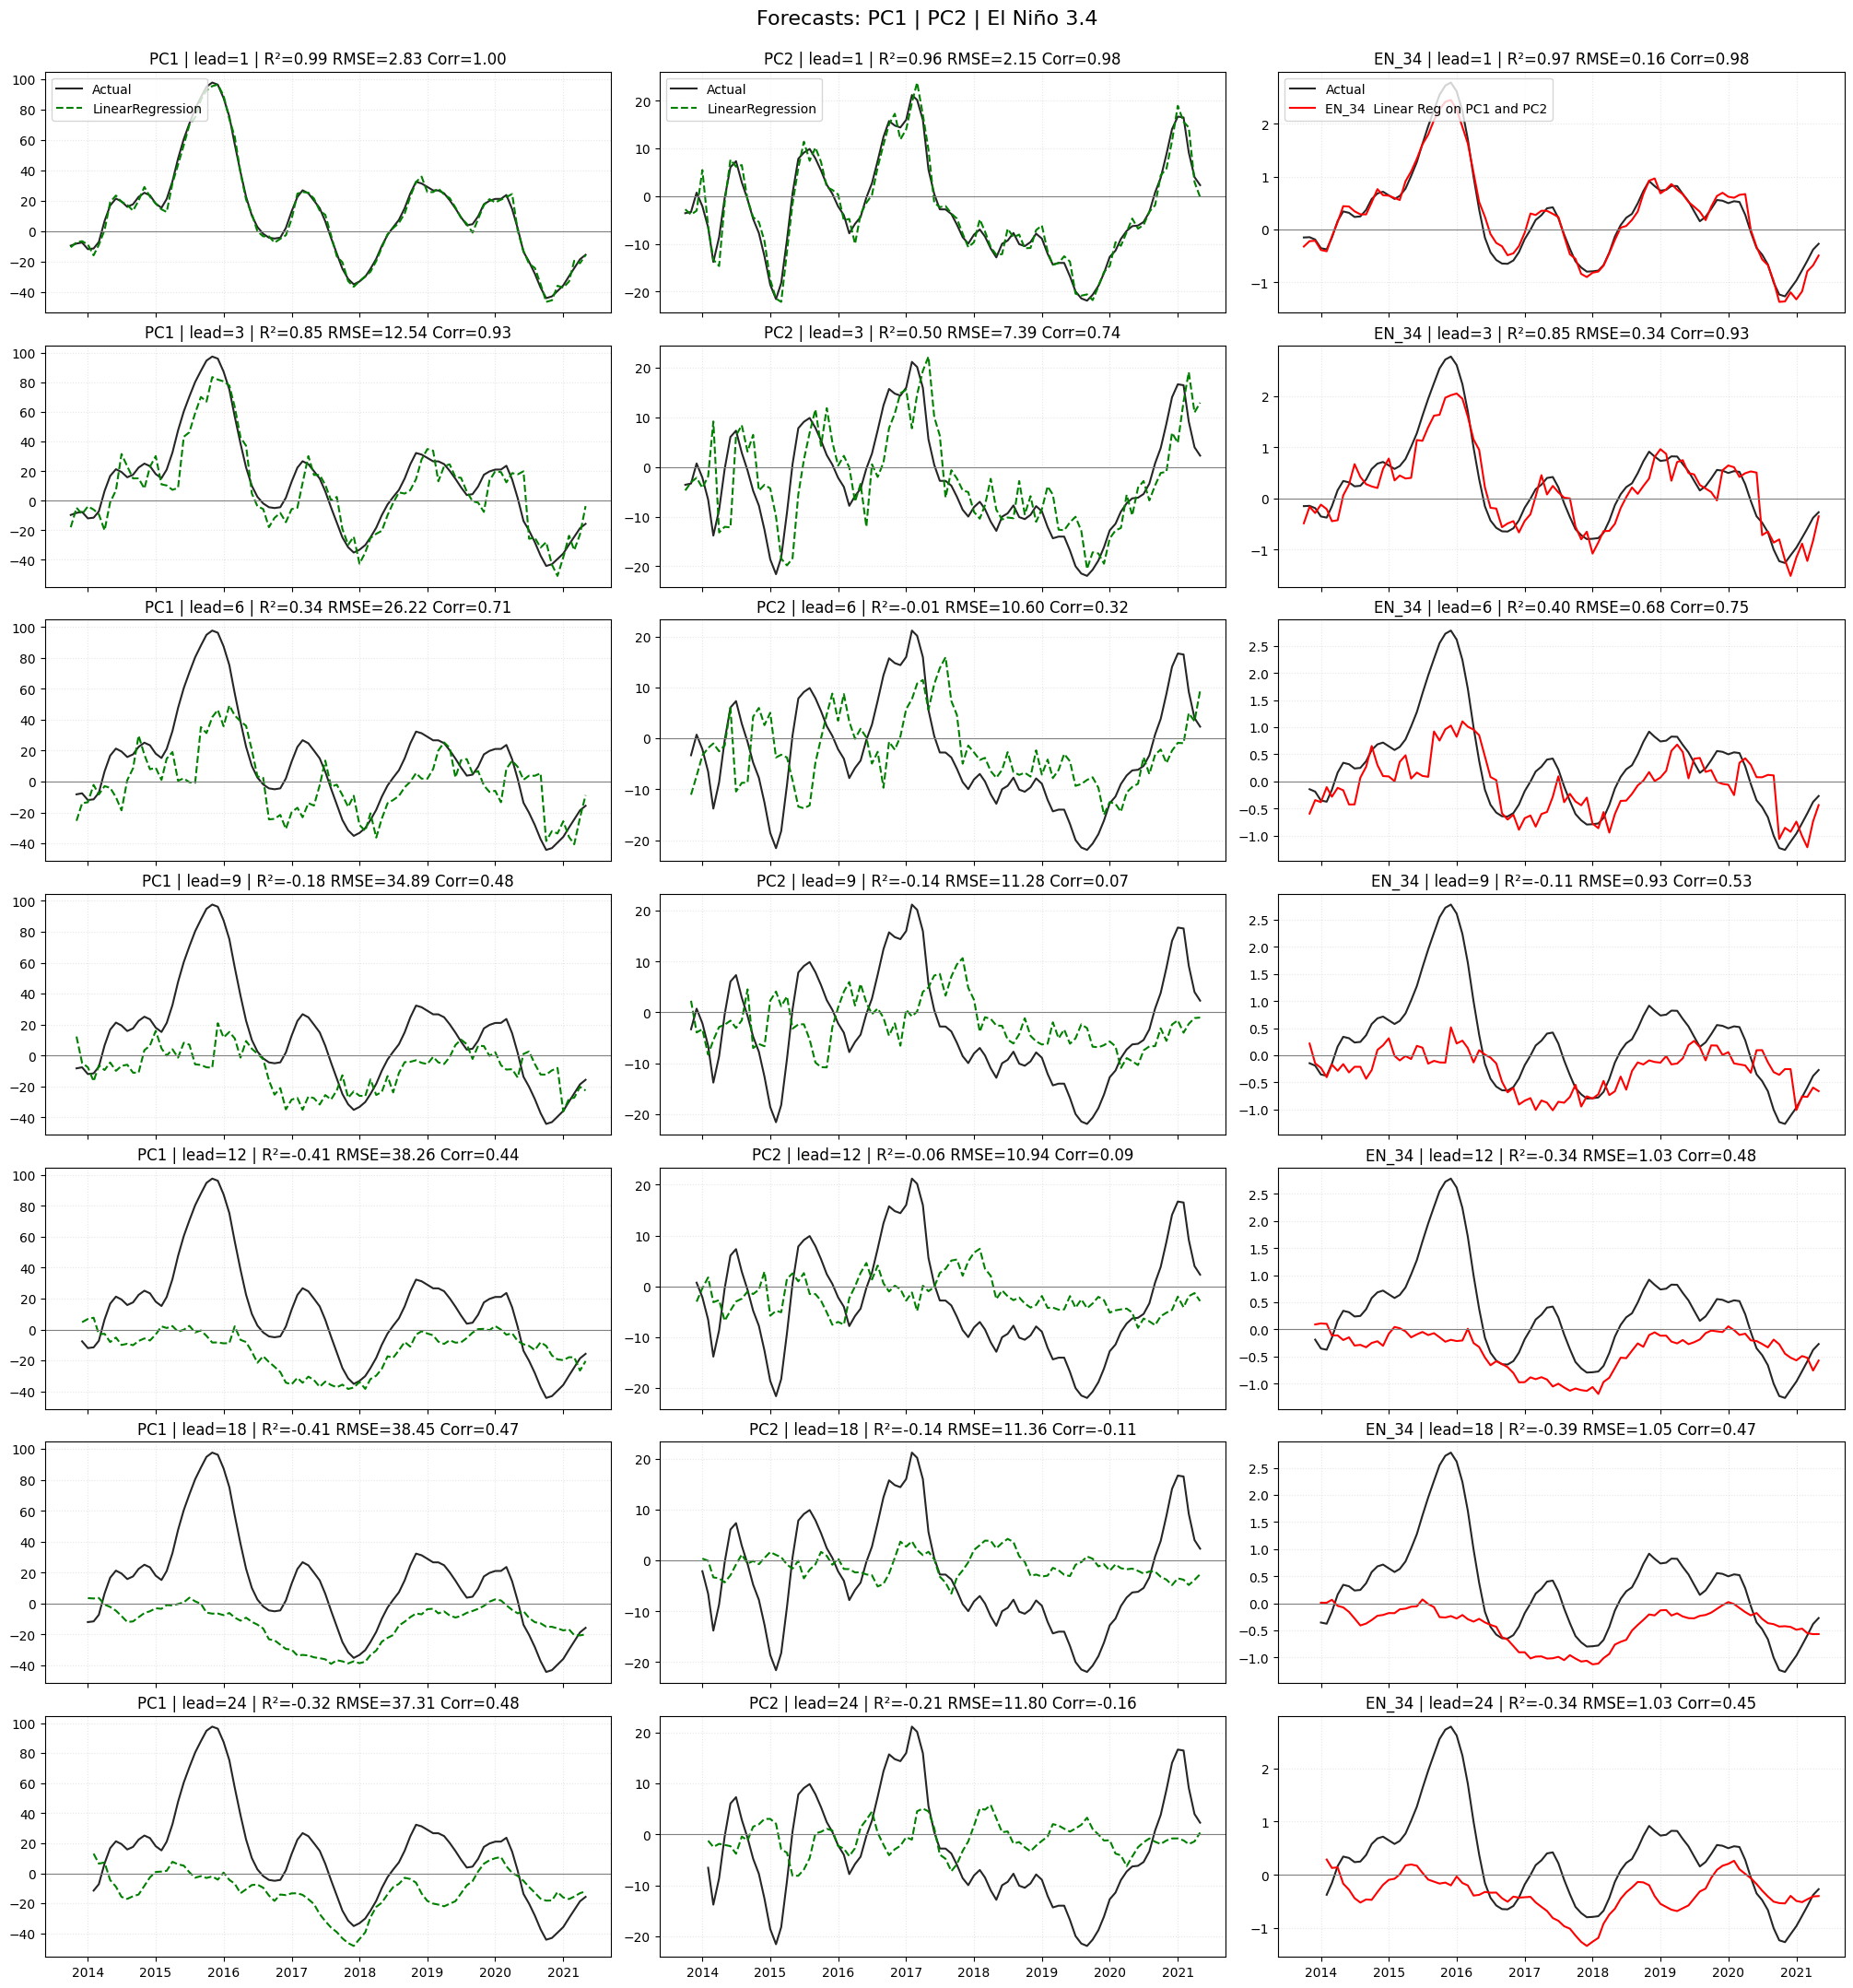

In [6]:
plot_test(LinearRegression, data=data, leads_to_plot=leads_to_plot, n_lags=window, model_name="LinearRegression")

### Prediction of SST PC1 and PC2 with Ridge Regression

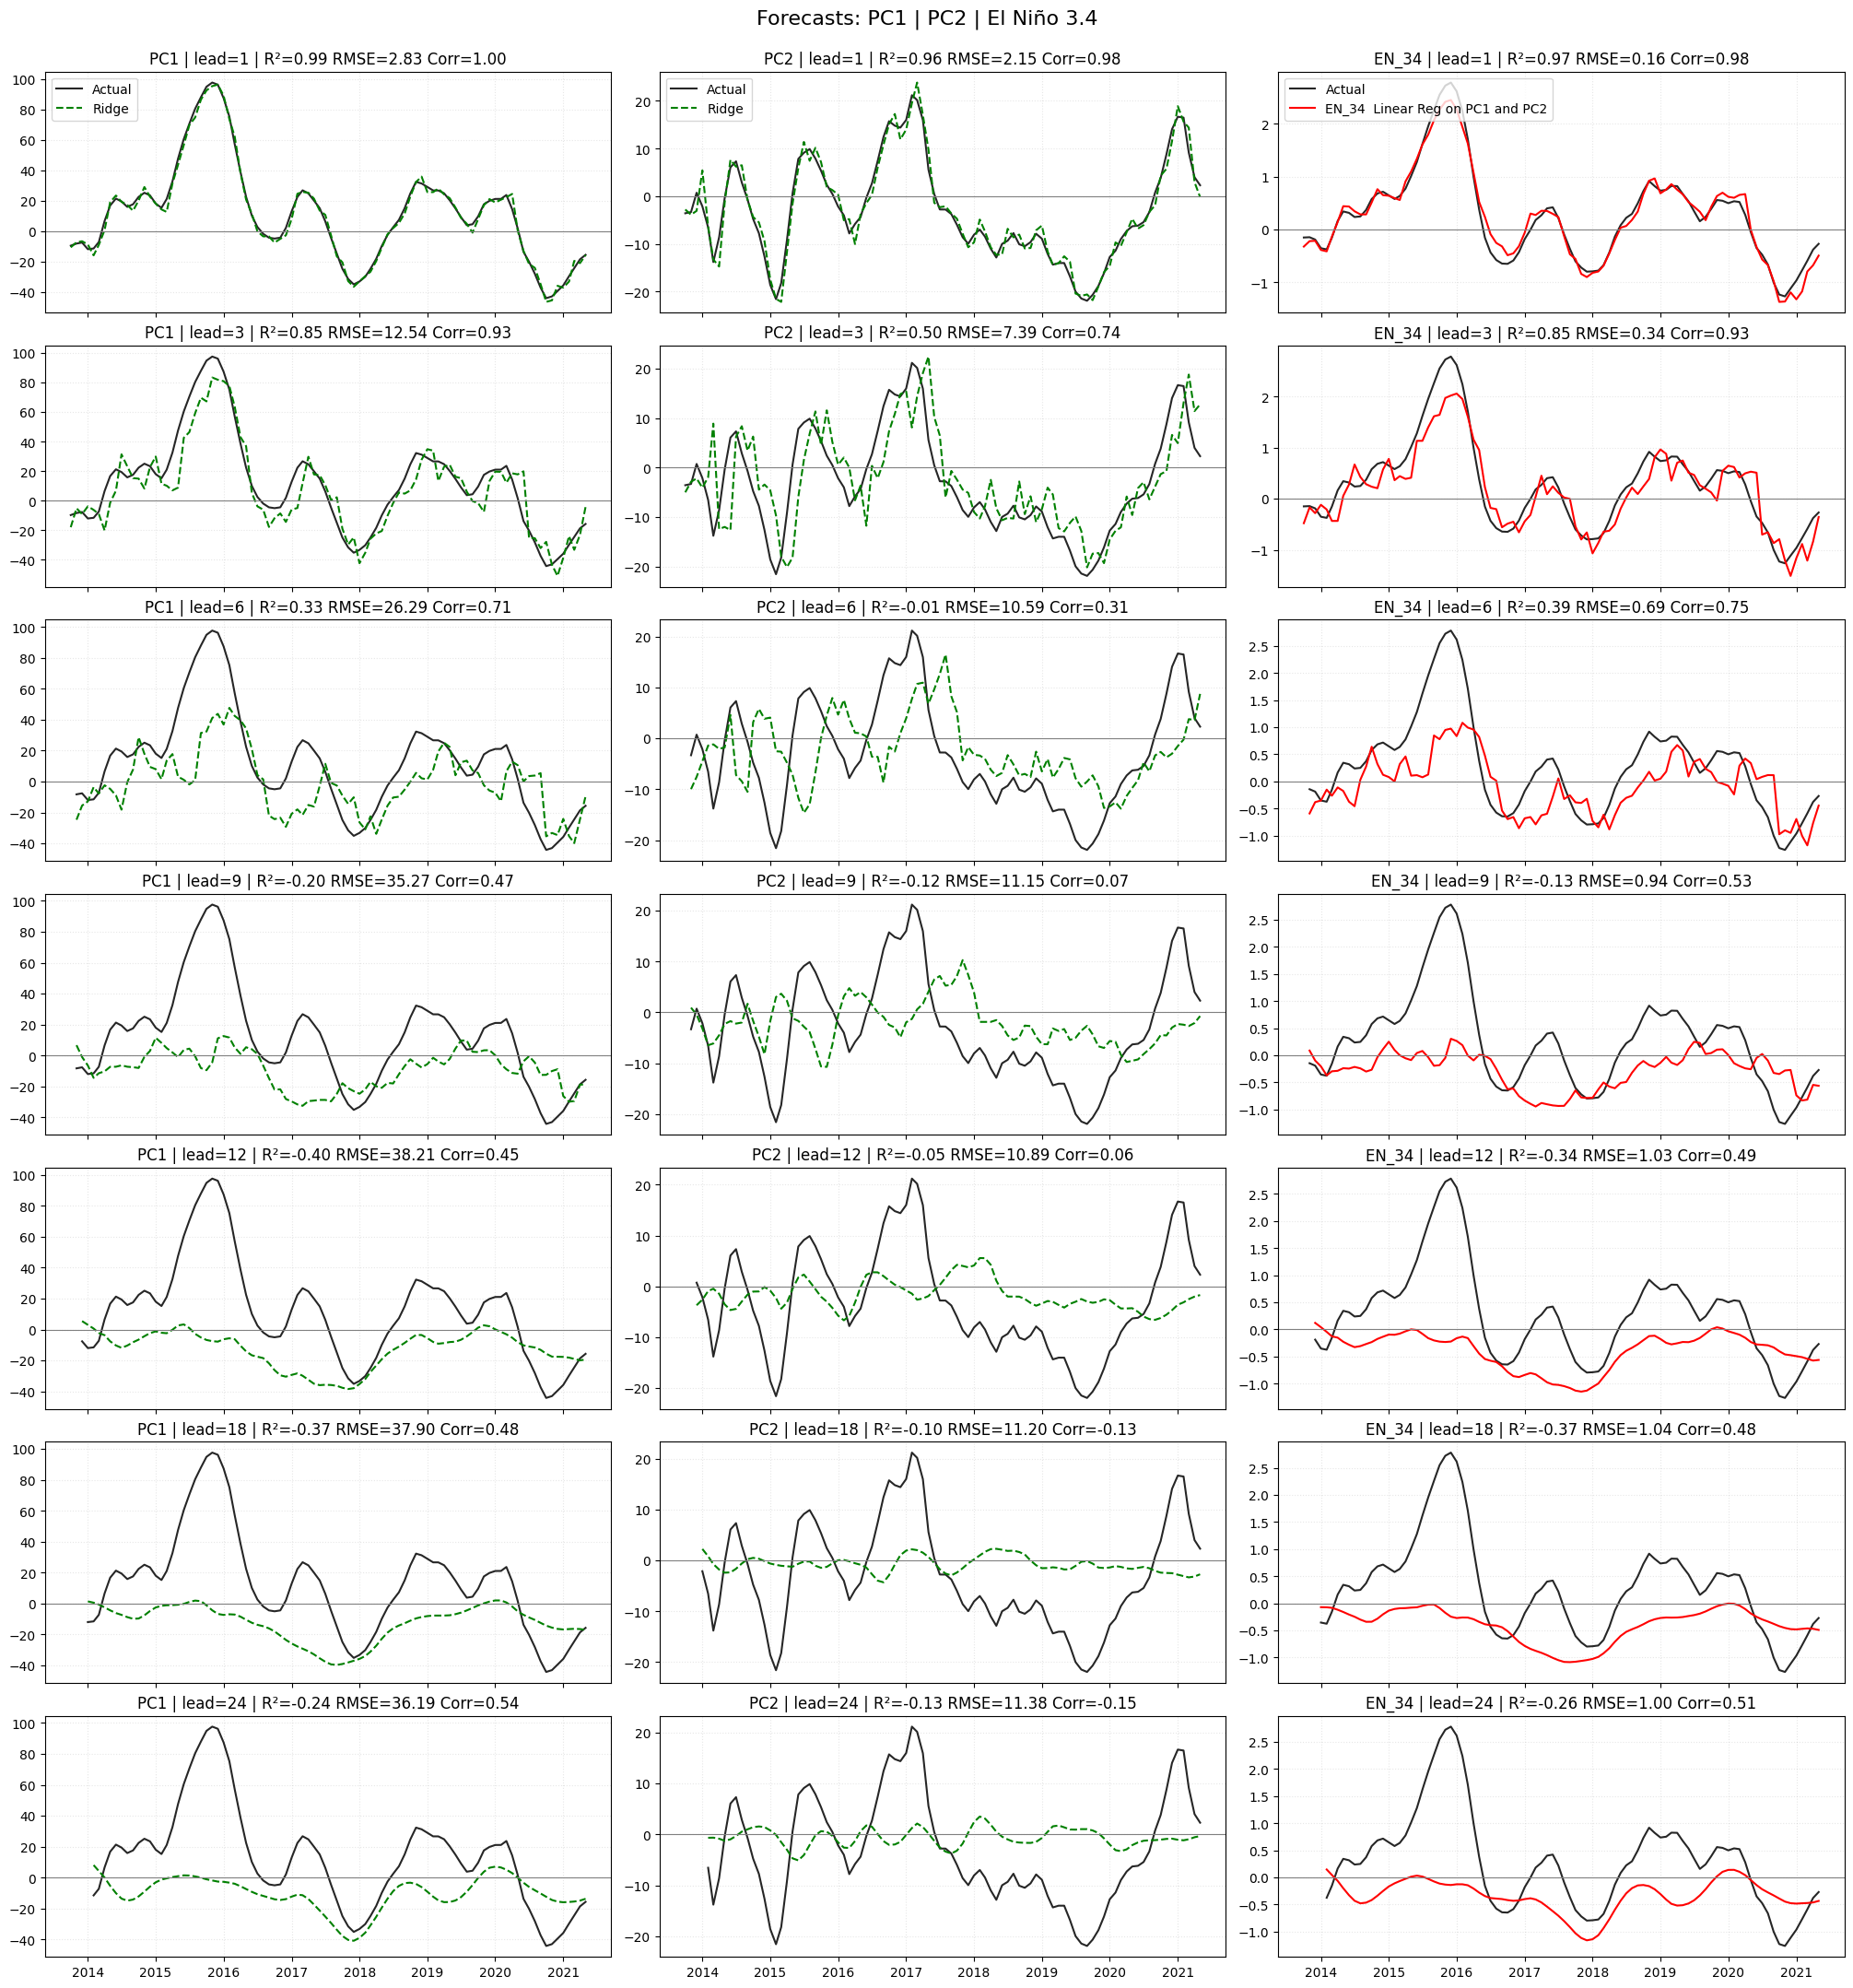

In [7]:
plot_test(RidgeCV, data=data, leads_to_plot=leads_to_plot, regressor_kwargs={"alphas": np.logspace(-5,5,50)}, n_lags=window, model_name="Ridge")

### Prediction of SST PC1 and PC2 with Random Forests

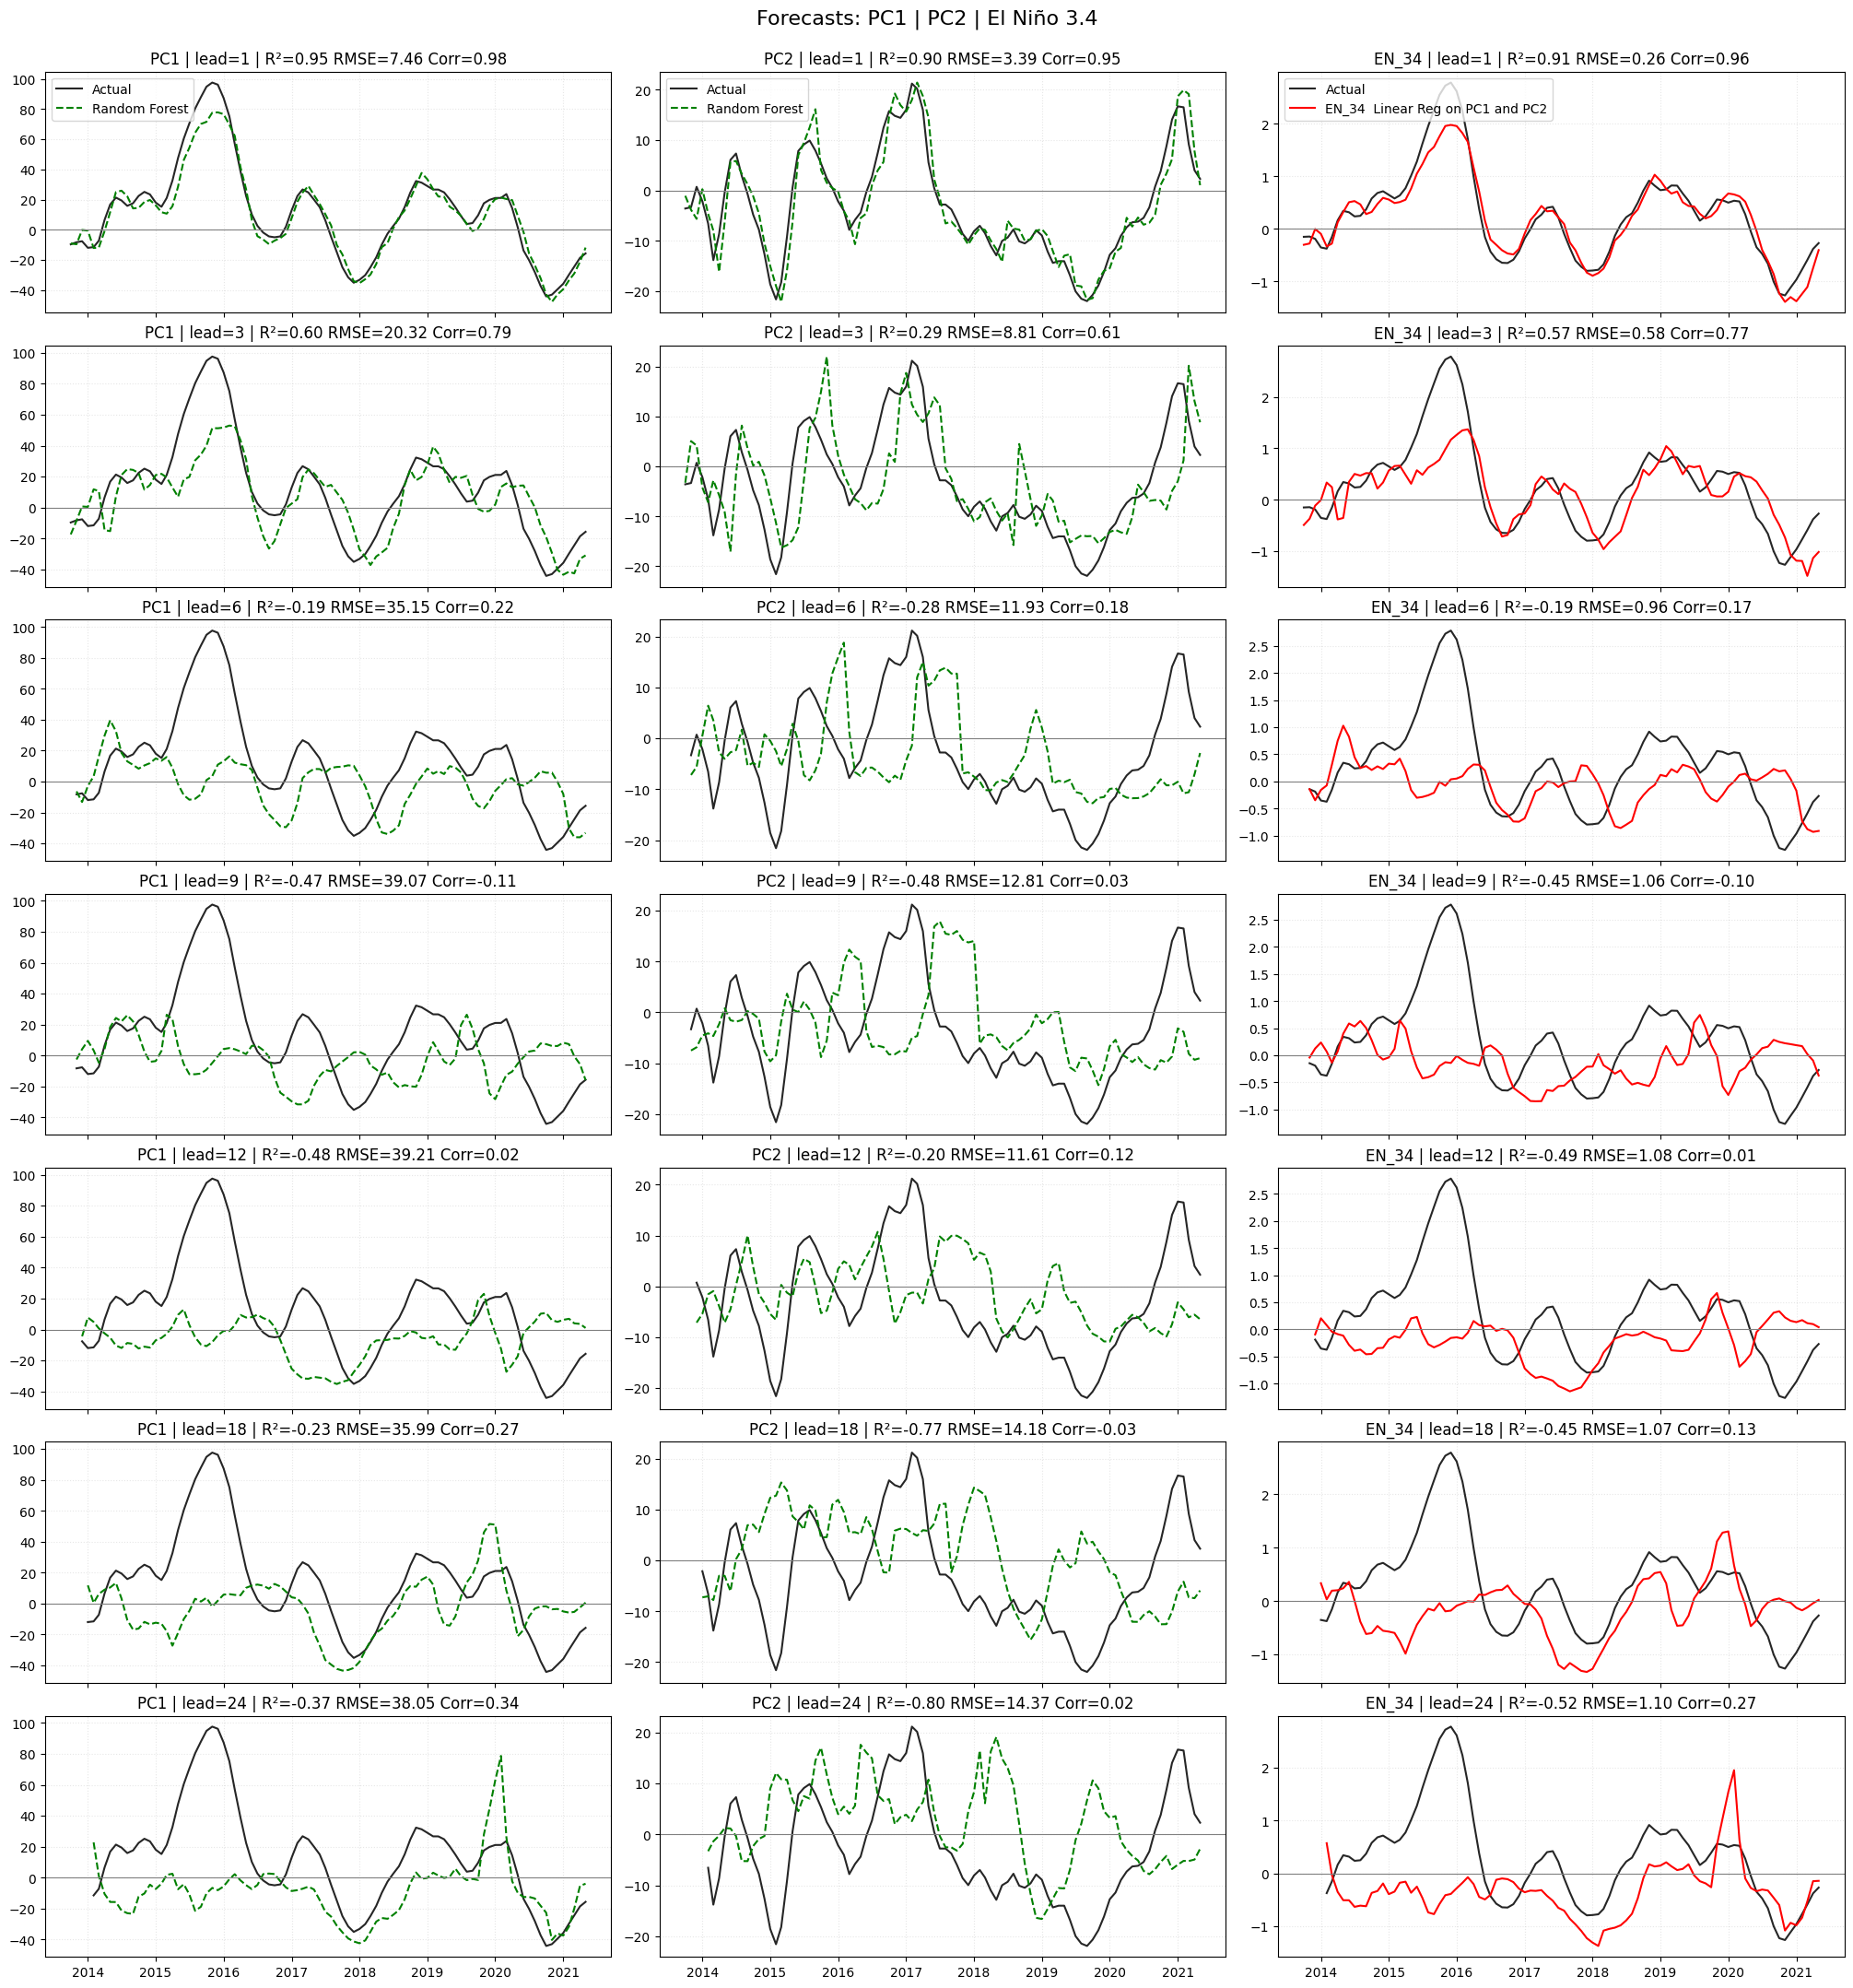

In [8]:
plot_test(
    model=RandomForestRegressor,
    data=data,
    leads_to_plot=leads_to_plot,
    n_lags=window,
    regressor_kwargs={
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "random_state": 42,
        "n_jobs": -1,
    },
    model_name="Random Forest")